## High resolution mapping of the breast cancer tumor microenvironment using integrated single cell, spatial and in situ analysis of FFPE tissue
Amanda Janesick, Robert Shelansky, Andrew Gottscho, Florian Wagner, Morgane Rouault, Ghezal Beliakoff, Michelli Faria de Oliveira, Andrew Kohlway, Jawad Abousoud, Carolyn Morrison, Tingsheng Yu Drennon, Syrus Mohabbat, Stephen Williams, 10x Development Teams, Sarah Taylor

October 20, 2023

Link to the paper: https://www.biorxiv.org/content/10.1101/2022.10.06.510405v1

Link to the data: https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast

Available for download from GitHub: https://github.com/10XGenomics/janesick_nature_comms_2023_companion
![image.png](./figures/F1.large.jpg)



### Xenium BRCA rep1 / rep2 preprocessing

This notebook preprocesses both public Xenium breast-cancer replicates independently. It reads supervised annotations from `data/Xemium/BRCA/Annotation/GSE243275_Barcode_Cell_Type_MatricesLY.xlsx`:

- rep1: `Xenium R1 Fig1-5 (supervised)`
- rep2: `Xenium R2 Fig1-5 (supervised)LY` (DCIS 1 / DCIS 2 labels corrected relative to the original R2 sheet)

For each replicate, the expression matrix, Xenium cell metadata, supervised labels, micron coordinates, and H&E/morphology pixel coordinates are aligned by barcode and saved with replicate-specific filenames under `data/Xemium/BRCA/Results/`.

In [1]:
# ## 2024.01.09 LLY add
# cd /mnt/lingyu/nfs_share2/Python/
# cp -r iSTAR/GSE243280/GSM7780153_Xenium_R1_Fig1-5_supervised.csv.gz Xenium/xenium-publication/GSM7780153_Xenium_R1_Fig1-5_supervised.csv.gz
# cd Xenium/xenium-publication/
# gunzip GSM7780153_Xenium_R1_Fig1-5_supervised.csv.gz
# cp -r GSM7780153_Xenium_R1_Fig1-5_supervised.csv cell_groups.csv


## 2024.01.09 Try to run this demo and gen the expression of one gene using Xunimum data
## using the Python 3(ipykernel) 在安装过程中默认的
## 2024.07.31 Update the ROI, using Polygon
## 2024.08.02 Xenium ground truth, using the sing cell data, not binned_spot 
## 2024.08.06 Xenium ground truth, using the sing cell data and binned_spot as ground truth
## 2024.08.07 add the TransImp results, using pseudo-visium
## 2026.06.20 copy form woody and see the Hist2Pheno results
##            FIneST env
## 2026.09.03 split former xenium-publication/ into Annotation/ (xlsx + paper CSVs)
##            and Results/ (h5ad, per-rep CSVs, QC); companion_functions.py -> BRCA_plot.py

## Load both replicates, align supervised cell types, and save h5ad/CSV outputs

### Xenium adata: cell_feature_matrix
See: Xenium Cell feature matrix

https://localhost:8888/notebooks/SpatialScope/Nuclei_Segmentation_ROIcompare.ipynb

See: Cell type spatial map

https://localhost:8888/notebooks/Xenium/janesick_nature_comms_2023_companion-main/companion_notebook_compare_ROI_istar.ipynb


In [2]:
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    """Find the Hist2Pheno root whether Jupyter starts at repo root or code/."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "code/Xenium_brca").is_dir() and (candidate / "data/Xemium").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the Hist2Pheno repository root")


REPO_ROOT = find_repo_root()
BRCA_ROOT = REPO_ROOT / "data/Xemium/BRCA"
ANNOTATION_DIR = BRCA_ROOT / "Annotation"
OUTPUT_DIR = BRCA_ROOT / "Results"
ANNOTATION_XLSX = ANNOTATION_DIR / "GSE243275_Barcode_Cell_Type_MatricesLY.xlsx"
XENIUM_LUNG_CODE = REPO_ROOT / "code/Xenium_lung"

DATASETS = {
    "rep1": {
        "replicate": 1,
        "data_dir": BRCA_ROOT / "human_breast_Xenium_rep1",
        "prefix": "Xenium_FFPE_Human_Breast_Cancer_Rep1",
        "annotation_sheet": "Xenium R1 Fig1-5 (supervised)",
    },
    "rep2": {
        "replicate": 2,
        "data_dir": BRCA_ROOT / "human_breast_Xenium_rep2",
        "prefix": "Xenium_FFPE_Human_Breast_Cancer_Rep2",
        "annotation_sheet": "Xenium R2 Fig1-5 (supervised)LY",
    },
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Repository:", REPO_ROOT)
print("Annotation directory:", ANNOTATION_DIR)
print("Annotation workbook:", ANNOTATION_XLSX.name)
print("Output directory:", OUTPUT_DIR)

Repository: /nobackup2/users/lingyu/Python/Hist2Pheno
Annotation directory: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Annotation
Annotation workbook: GSE243275_Barcode_Cell_Type_MatricesLY.xlsx
Output directory: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results


In [3]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

if str(XENIUM_LUNG_CODE) not in sys.path:
    sys.path.insert(0, str(XENIUM_LUNG_CODE))
import tifffile
from xenium_coords import (
    XENIUM_UM_PER_PX,
    add_he_pixel_columns,
    alignment_isotropic_scale,
    load_xenium_imagealignment_matrix,
    microns_to_he_pixels_via_alignment,
)


def _barcode_index(values: pd.Series | pd.Index) -> pd.Index:
    """Normalize Excel numeric barcodes and Xenium string barcodes identically."""
    return pd.Index(pd.Series(values).astype(str).str.replace(r"\.0$", "", regex=True))


def preprocess_xenium_brca(name: str, config: dict):
    prefix = config["prefix"]
    matrix_path = config["data_dir"] / f"{prefix}_cell_feature_matrix.h5"
    cells_path = config["data_dir"] / f"{prefix}_cells.csv.gz"
    required = [ANNOTATION_XLSX, matrix_path, cells_path]
    missing = [str(path) for path in required if not path.is_file()]
    if missing:
        raise FileNotFoundError("Missing required input(s):\n" + "\n".join(missing))

    adata = sc.read_10x_h5(matrix_path)
    adata.var_names_make_unique()
    adata.obs_names = _barcode_index(adata.obs_names)

    cells = pd.read_csv(cells_path)
    annotation = pd.read_excel(ANNOTATION_XLSX, sheet_name=config["annotation_sheet"])
    if not {"cell_id", "x_centroid", "y_centroid"}.issubset(cells.columns):
        raise ValueError(f"{cells_path.name} lacks required cell/centroid columns")
    if not {"Barcode", "Cluster"}.issubset(annotation.columns):
        raise ValueError(f"Sheet {config['annotation_sheet']!r} lacks Barcode/Cluster")

    cells = cells.copy()
    annotation = annotation[["Barcode", "Cluster"]].copy()
    cells["barcode"] = _barcode_index(cells["cell_id"])
    annotation["barcode"] = _barcode_index(annotation["Barcode"])
    if cells["barcode"].duplicated().any() or annotation["barcode"].duplicated().any():
        raise ValueError(f"Duplicate barcodes detected for {name}")

    merged = cells.merge(
        annotation,
        on="barcode",
        how="left",
        validate="one_to_one",
        indicator=True,
    )
    unmatched_annotation = int((merged["_merge"] != "both").sum())
    merged = merged.drop(columns="_merge").set_index("barcode", drop=False)

    missing_metadata = adata.obs_names.difference(merged.index)
    extra_metadata = merged.index.difference(adata.obs_names)
    if len(missing_metadata) or len(extra_metadata):
        raise ValueError(
            f"{name}: matrix/cell metadata mismatch: "
            f"missing={len(missing_metadata)}, extra={len(extra_metadata)}"
        )
    merged = merged.loc[adata.obs_names].copy()
    merged["cell_type_raw"] = merged["Cluster"].fillna("Unlabeled")
    merged["cell_type"] = merged["cell_type_raw"].str.replace("_", " ", regex=False)
    merged["sample"] = name
    merged["replicate"] = config["replicate"]
    # Morphology pixels (DAPI / 0.2125 µm/px) — not the post-Xenium HE TIFF.
    merged_he = add_he_pixel_columns(merged, coord_units="um")
    merged_he = merged_he.rename(
        columns={"X_pix_HE": "X_pix_morph", "Y_pix_HE": "Y_pix_morph"}
    )
    alignment_csv = config["data_dir"] / f"{prefix}_he_imagealignment.csv"
    he_tif = config["data_dir"] / f"{prefix}_he_image.tif"
    if not alignment_csv.is_file():
        raise FileNotFoundError(f"Missing HE alignment matrix: {alignment_csv}")
    if not he_tif.is_file():
        raise FileNotFoundError(f"Missing HE image: {he_tif}")
    align_M = load_xenium_imagealignment_matrix(alignment_csv)
    x_he, y_he = microns_to_he_pixels_via_alignment(
        merged_he["x_centroid"], merged_he["y_centroid"], align_M
    )
    y_idx = int(merged_he.columns.get_loc("y_centroid")) + 1
    merged_he.insert(y_idx, "X_pix_HE", x_he)
    merged_he.insert(y_idx + 1, "Y_pix_HE", y_he)
    with tifffile.TiffFile(he_tif) as tiff:
        he_height, he_width = tiff.pages[0].shape[:2]
    inside_he = (
        (merged_he["X_pix_HE"] >= 0)
        & (merged_he["X_pix_HE"] < he_width)
        & (merged_he["Y_pix_HE"] >= 0)
        & (merged_he["Y_pix_HE"] < he_height)
    )
    he_scale = alignment_isotropic_scale(align_M)
    he_um_per_px = XENIUM_UM_PER_PX * he_scale

    adata.obsm["spatial"] = merged_he[["x_centroid", "y_centroid"]].to_numpy(float)
    adata.obsm["spatial_HE"] = merged_he[["X_pix_HE", "Y_pix_HE"]].to_numpy(float)
    for column in merged_he.columns:
        if column == "barcode":
            continue
        adata.obs[column] = merged_he[column].to_numpy()

    adata.obs["expression_counts"] = np.asarray(adata.X.sum(axis=1)).ravel()
    if sparse.issparse(adata.X):
        adata.obs["n_genes_by_counts"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()
    else:
        adata.obs["n_genes_by_counts"] = (adata.X > 0).sum(axis=1)
    adata.uns["dataset"] = name
    adata.uns["replicate"] = config["replicate"]
    adata.uns["annotation_workbook"] = ANNOTATION_XLSX.name
    adata.uns["annotation_sheet"] = config["annotation_sheet"]
    adata.uns["coordinate_systems"] = {
        "spatial": "Xenium morphology coordinates in microns",
        "spatial_HE": (
            "post-Xenium HE TIFF pixels via inv(he_imagealignment) "
            f"@ (microns / {XENIUM_UM_PER_PX} um/px)"
        ),
        "X_pix_morph": f"Xenium morphology pixels ({XENIUM_UM_PER_PX} um/px)",
    }
    adata.uns["he_image"] = he_tif.name
    adata.uns["he_imagealignment"] = alignment_csv.name
    adata.uns["he_width"] = int(he_width)
    adata.uns["he_height"] = int(he_height)
    adata.uns["he_alignment_scale"] = float(he_scale)
    adata.uns["he_um_per_px"] = float(he_um_per_px)
    adata.uns["n_cells_inside_he"] = int(inside_he.sum())

    stem = f"xenium_brca_{name}"
    annotation_csv = OUTPUT_DIR / f"{stem}_cell_groups.csv"
    cell_info_csv = OUTPUT_DIR / f"{stem}_cell_info_HE_by_annotation.csv"
    h5ad_path = OUTPUT_DIR / f"{stem}_cell_feature_matrix_annotated.h5ad"
    annotation.drop(columns="barcode").to_csv(annotation_csv, index=False)
    merged_he.reset_index(drop=True).to_csv(cell_info_csv, index=False)
    adata.write_h5ad(h5ad_path, compression="gzip")

    summary = {
        "dataset": name,
        "replicate": config["replicate"],
        "n_cells": adata.n_obs,
        "n_genes": adata.n_vars,
        "n_cell_types": int(merged_he["cell_type"].nunique()),
        "n_unmatched_annotations": unmatched_annotation,
        "n_inside_he": int(inside_he.sum()),
        "frac_inside_he": float(inside_he.mean()),
        "he_width": int(he_width),
        "he_height": int(he_height),
        "he_um_per_px": float(he_um_per_px),
        "annotation_sheet": config["annotation_sheet"],
        "h5ad": h5ad_path.name,
        "cell_info_csv": cell_info_csv.name,
        "annotation_csv": annotation_csv.name,
    }
    print(
        f"{name}: {adata.n_obs:,} cells x {adata.n_vars:,} genes; "
        f"inside HE {int(inside_he.sum()):,}/{adata.n_obs:,} "
        f"({he_width}x{he_height} px, {he_um_per_px:.4f} um/px); "
        f"saved {h5ad_path.name}"
    )
    return adata, merged_he, summary


processed = {}
summaries = []
for dataset_name, dataset_config in DATASETS.items():
    adata, cell_info, summary = preprocess_xenium_brca(dataset_name, dataset_config)
    processed[dataset_name] = {"adata": adata, "cell_info": cell_info}
    summaries.append(summary)

summary_df = pd.DataFrame(summaries)
summary_path = OUTPUT_DIR / "xenium_brca_preprocessing_summary.csv"
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print("Saved summary:", summary_path)

rep1: 167,780 cells x 313 genes; saved xenium_brca_rep1_cell_feature_matrix_annotated.h5ad
rep2: 118,752 cells x 313 genes; saved xenium_brca_rep2_cell_feature_matrix_annotated.h5ad


,dataset,replicate,n_cells,n_genes,n_cell_types,n_unmatched_annotations,annotation_sheet,h5ad,cell_info_csv,annotation_csv
0,rep1,1,167780,313,20,0,Xenium R1 Fig1-5 (supervised),xenium_brca_rep1_cell_feature_matrix_annotated...,xenium_brca_rep1_cell_info_HE_by_annotation.csv,xenium_brca_rep1_cell_groups.csv
1,rep2,2,118752,313,20,0,Xenium R2 Fig1-5 (supervised)LY,xenium_brca_rep2_cell_feature_matrix_annotated...,xenium_brca_rep2_cell_info_HE_by_annotation.csv,xenium_brca_rep2_cell_groups.csv


Saved summary: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/xenium_brca_preprocessing_summary.csv


### Coordinate preprocessing and QC (rep1 + rep2)

Each replicate keeps two explicitly named coordinate arrays:

- `adata.obsm['spatial']`: Xenium `x_centroid` / `y_centroid` in microns (µm).
- `adata.obsm['spatial_HE']`: **post-Xenium HE TIFF pixels**, from 10x `*_he_imagealignment.csv`:

  `HE_px = inv(M) @ (microns / 0.2125)`

Do **not** use morphology 0.2125 µm/px as the HE TIFF pixel size. That canvas is larger than `*_he_image.tif` (rep1 HE is 27587×20511, morphology pixels go to ~35400×25800) and breaks StarDist / UNI matching.

`cell_info` also stores `X_pix_morph` / `Y_pix_morph` (microns / 0.2125) for reference. Annotations are joined by `cell_id` ↔ `Barcode`, not by row position.

In [4]:
qc_rows = []
for dataset_name, result in processed.items():
    adata = result["adata"]
    cell_info = result["cell_info"]
    assert adata.n_obs == len(cell_info)
    assert adata.obs_names.equals(cell_info.index)
    assert np.allclose(adata.obsm["spatial"], cell_info[["x_centroid", "y_centroid"]])
    assert np.allclose(adata.obsm["spatial_HE"], cell_info[["X_pix_HE", "Y_pix_HE"]])

    qc_rows.append(
        {
            "dataset": dataset_name,
            "n_cells": adata.n_obs,
            "n_genes": adata.n_vars,
            "x_um_min": cell_info["x_centroid"].min(),
            "x_um_max": cell_info["x_centroid"].max(),
            "y_um_min": cell_info["y_centroid"].min(),
            "y_um_max": cell_info["y_centroid"].max(),
            "x_HE_px_min": cell_info["X_pix_HE"].min(),
            "x_HE_px_max": cell_info["X_pix_HE"].max(),
            "y_HE_px_min": cell_info["Y_pix_HE"].min(),
            "y_HE_px_max": cell_info["Y_pix_HE"].max(),
            "he_width": adata.uns.get("he_width"),
            "he_height": adata.uns.get("he_height"),
            "n_inside_he": adata.uns.get("n_cells_inside_he"),
            "he_um_per_px": adata.uns.get("he_um_per_px"),
            "missing_cell_type": int(cell_info["Cluster"].isna().sum()),
        }
    )

qc_df = pd.DataFrame(qc_rows)
qc_path = OUTPUT_DIR / "xenium_brca_preprocessing_qc.csv"
qc_df.to_csv(qc_path, index=False)
display(qc_df)

for dataset_name, result in processed.items():
    print(f"\n{dataset_name} cell-type counts")
    display(result["cell_info"]["cell_type"].value_counts().rename("n_cells").to_frame())

print("Saved QC:", qc_path)

,dataset,n_cells,n_genes,x_um_min,x_um_max,y_um_min,y_um_max,x_HE_px_min,x_HE_px_max,y_HE_px_min,y_HE_px_max,missing_cell_type
0,rep1,167780,313,2.132516,7523.086865,1.367156,5476.266113,10.035370,35402.761719,6.433673,25770.664062,0
1,rep2,118752,313,2.410377,7522.187891,1.504470,5472.492993,11.342951,35398.531250,7.079857,25752.908203,0



rep1 cell-type counts


,n_cells
cell_type,
Stromal,41422
Invasive Tumor,34374
DCIS 1,12923
DCIS 2,11683
Macrophages 1,11174
Endothelial,8931
Unlabeled,8554
CD4+ T Cells,8453
Myoepi ACTA2+,7078



rep2 cell-type counts


,n_cells
cell_type,
Stromal,38644
Invasive Tumor,15759
DCIS 2,10024
Macrophages 1,8052
DCIS 1,7171
Endothelial,6699
Myoepi ACTA2+,6062
CD4+ T Cells,5940
CD8+ T Cells,4948


Saved QC: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/xenium_brca_preprocessing_qc.csv


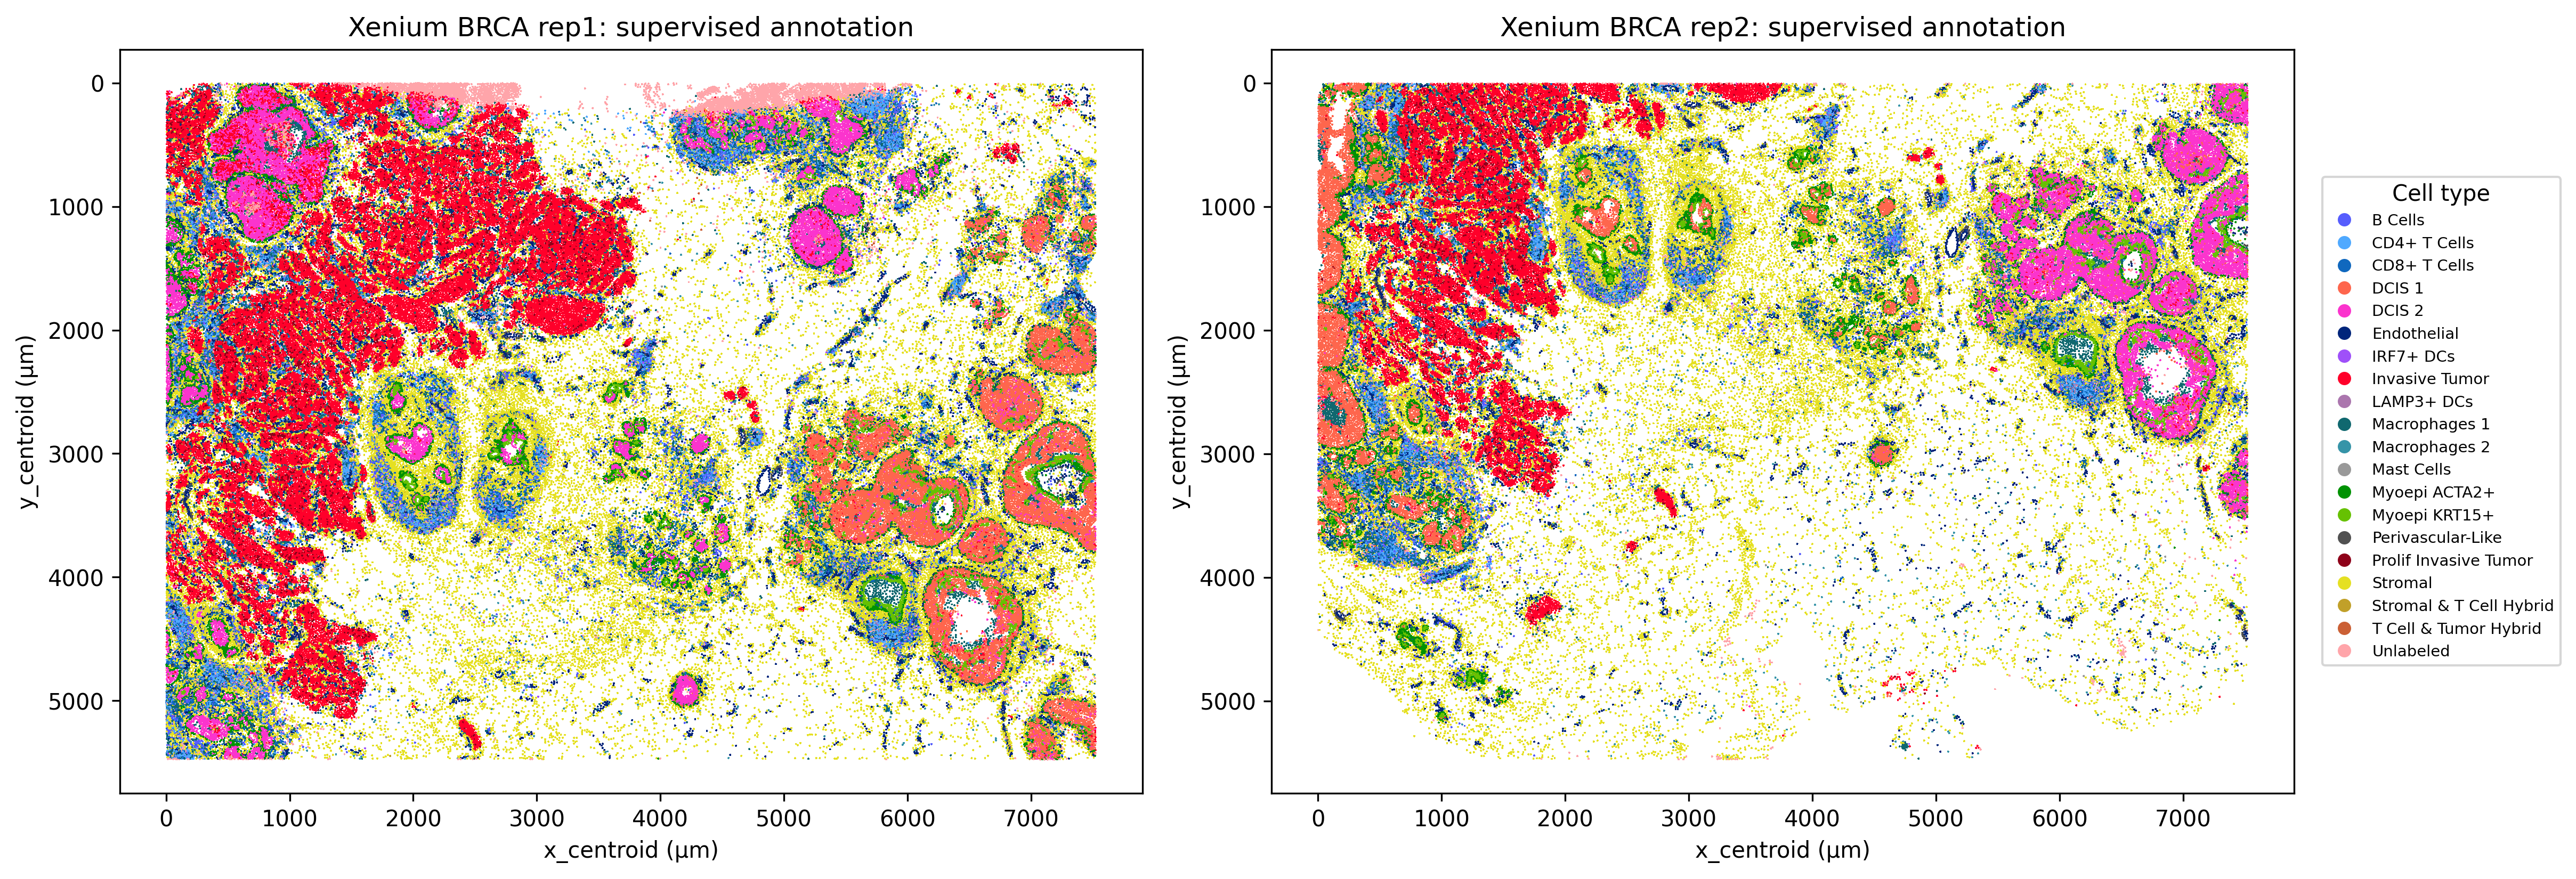

Saved plot: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/xenium_brca_rep1_rep2_annotation_spatial_qc.png


In [5]:
import sys

import matplotlib.pyplot as plt

# Spatial annotation QC for both replicates (micron coordinate system).
# Paper colors use underscored names (DCIS_1); this notebook stores display
# names with spaces (DCIS 1). Map both spellings to the same hex.
_brca_code = REPO_ROOT / "code/Xenium_brca"
if str(_brca_code) not in sys.path:
    sys.path.insert(0, str(_brca_code))
from BRCA_plot import ctype_hex_map

cell_type_colors = {}
for name, hex_color in ctype_hex_map.items():
    cell_type_colors[name] = hex_color
    cell_type_colors[name.replace("_", " ")] = hex_color

present_types = set().union(
    *(set(result["cell_info"]["cell_type"].unique()) for result in processed.values())
)
missing_palette = sorted(present_types - set(cell_type_colors))
if missing_palette:
    raise KeyError(f"Cell types missing from BRCA_plot.ctype_hex_map: {missing_palette}")

legend_order = [
    name.replace("_", " ")
    for name in ctype_hex_map
    if name.replace("_", " ") in present_types or name in present_types
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=300, constrained_layout=True)
for ax, (dataset_name, result) in zip(axes, processed.items()):
    plot_df = result["cell_info"]
    colors = plot_df["cell_type"].map(cell_type_colors)
    ax.scatter(
        plot_df["x_centroid"],
        plot_df["y_centroid"],
        s=0.5,
        c=list(colors),
        linewidths=0,
        antialiased=False,
        rasterized=False,
    )
    ax.set_title(f"Xenium BRCA {dataset_name}: supervised annotation")
    ax.set_xlabel("x_centroid (µm)")
    ax.set_ylabel("y_centroid (µm)")
    ax.set_aspect("equal")
    ax.invert_yaxis()

legend_handles = [
    plt.Line2D(
        [0], [0], marker="o", linestyle="", color=cell_type_colors[cell_type],
        label=cell_type, markersize=5,
    )
    for cell_type in legend_order
]
axes[-1].legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Cell type",
    fontsize=7,
)
plot_path = OUTPUT_DIR / "xenium_brca_rep1_rep2_annotation_spatial_qc.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved plot:", plot_path)

Saved: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/xenium_brca_rep1_rep2_pooled_celltype_distribution.png


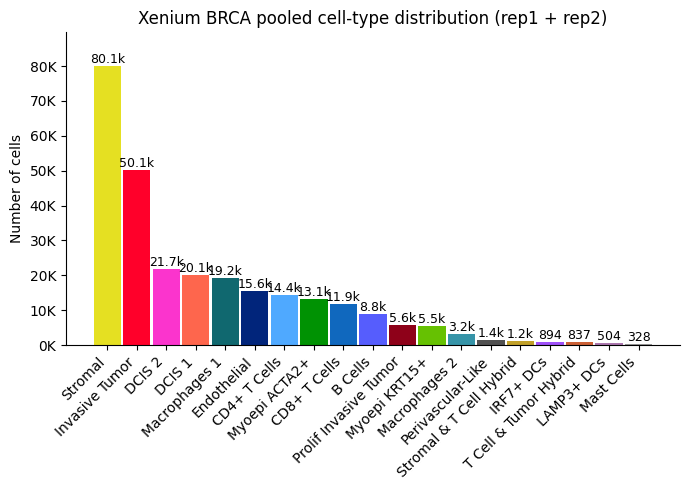

In [6]:
import sys

_brca_code = REPO_ROOT / "code/Xenium_brca"
if str(_brca_code) not in sys.path:
    sys.path.insert(0, str(_brca_code))
from BRCA_plot import plot_pooled_celltype_distribution

# Pooled cell-type counts across both Xenium BRCA replicates.
# Colors come from BRCA_plot.ctype_hex_map (same map as the spatial QC plot).
cells_by_acq = {
    dataset_name: result["cell_info"]
    for dataset_name, result in processed.items()
}
plot_pooled_celltype_distribution(
    cells_by_acq,
    celltype_col="cell_type",
    exclude_unknown=True,
    figsize=(7, 5),
    save_path=OUTPUT_DIR / "xenium_brca_rep1_rep2_pooled_celltype_distribution.png",
)

## HE / StarDist QC and ERBB2 expression

1. StarDist nuclei centroids on the HE TIFF pixel canvas (`centroid_x` / `centroid_y`).
2. `ERBB2` from raw Xenium `cell_feature_matrix.h5` + `cells.csv.gz` (micron coords).
3. `ERBB2` from the saved annotated h5ad (`spatial` = µm; also show `spatial_HE`).


Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image_Float_prob0.01_nms_0.3.csv n= 252179
      centroid_x  centroid_y
min         3.64        2.03
max     27552.89    20499.66
mean    11750.11    11509.71


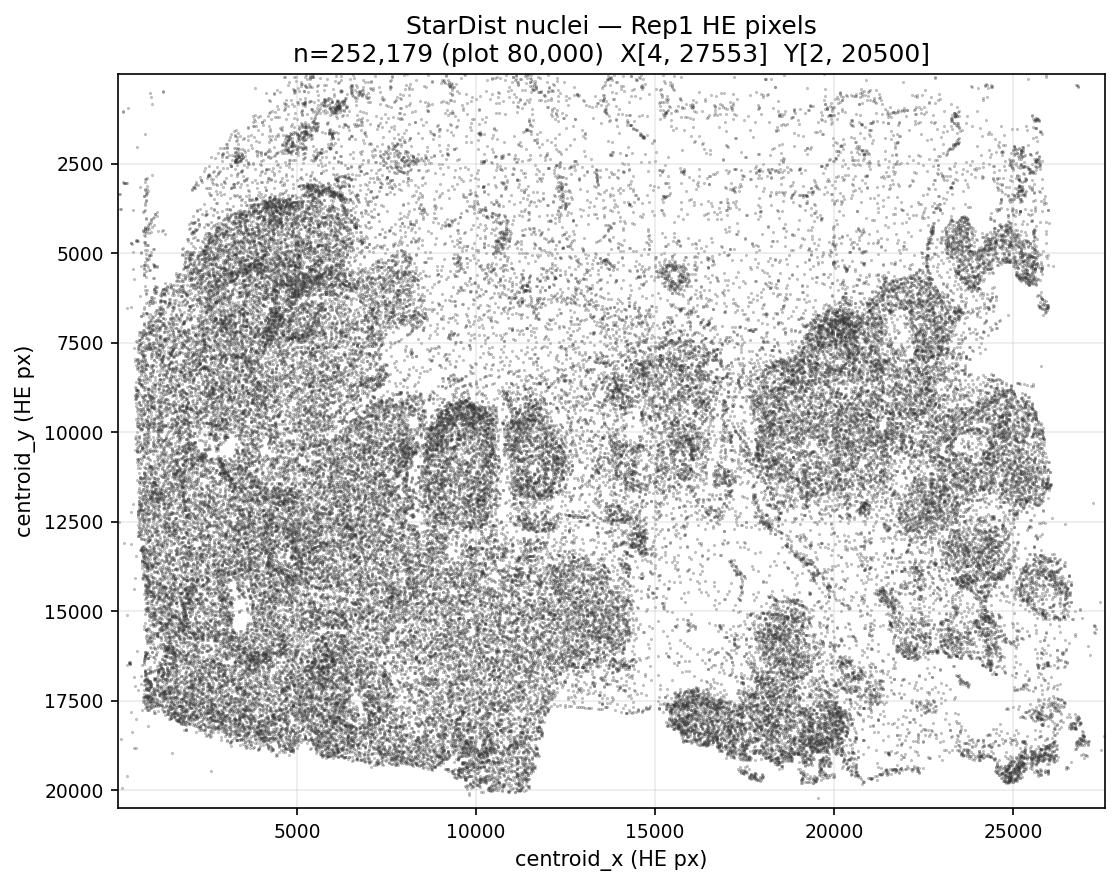

Saved: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/xenium_brca_rep1_stardist_centroid_scatter.png


In [7]:
## StarDist nuclei scatter (HE TIFF pixel coordinates)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse notebook paths when available; otherwise resolve from this file.
try:
    _brca_root = BRCA_ROOT
    _out_dir = OUTPUT_DIR
except NameError:
    _repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno")
    _brca_root = _repo / "data/Xemium/BRCA"
    _out_dir = _brca_root / "Results"
    _out_dir.mkdir(parents=True, exist_ok=True)

stardist_csv = (
    _brca_root
    / "StarDist_Segment"
    / "Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image"
    / "Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image_Float_prob0.01_nms_0.3.csv"
)
star = pd.read_csv(stardist_csv)
print(stardist_csv.name, "n=", len(star))
print(star[["centroid_x", "centroid_y"]].describe().loc[["min", "max", "mean"]].round(2))

# Subsample for plotting speed (full ~252k points).
rng = np.random.default_rng(0)
n_plot = min(80_000, len(star))
idx = rng.choice(len(star), size=n_plot, replace=False)
plot_df = star.iloc[idx]

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.scatter(
    plot_df["centroid_x"],
    plot_df["centroid_y"],
    s=0.2,
    c="0.2",
    alpha=0.35,
    rasterized=True,
)
ax.set_xlabel("centroid_x (HE px)")
ax.set_ylabel("centroid_y (HE px)")
ax.set_title(
    f"StarDist nuclei — Rep1 HE pixels\n"
    f"n={len(star):,} (plot {n_plot:,})  "
    f"X[{star['centroid_x'].min():.0f}, {star['centroid_x'].max():.0f}]  "
    f"Y[{star['centroid_y'].min():.0f}, {star['centroid_y'].max():.0f}]"
)
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()  # image-style: y increases downward
ax.tick_params(axis="both", which="both", labelsize=9)
ax.grid(True, alpha=0.25)
# Force visible numeric ranges on both axes
ax.set_xlim(star["centroid_x"].min(), star["centroid_x"].max())
ax.set_ylim(star["centroid_y"].max(), star["centroid_y"].min())  # inverted
fig.tight_layout()
out = _out_dir / "xenium_brca_rep1_stardist_centroid_scatter.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out)


raw ERBB2: n=167,780  nonzero=86.6%  max=114  Xµm[2.1,7523.1]  Yµm[1.4,5476.3]


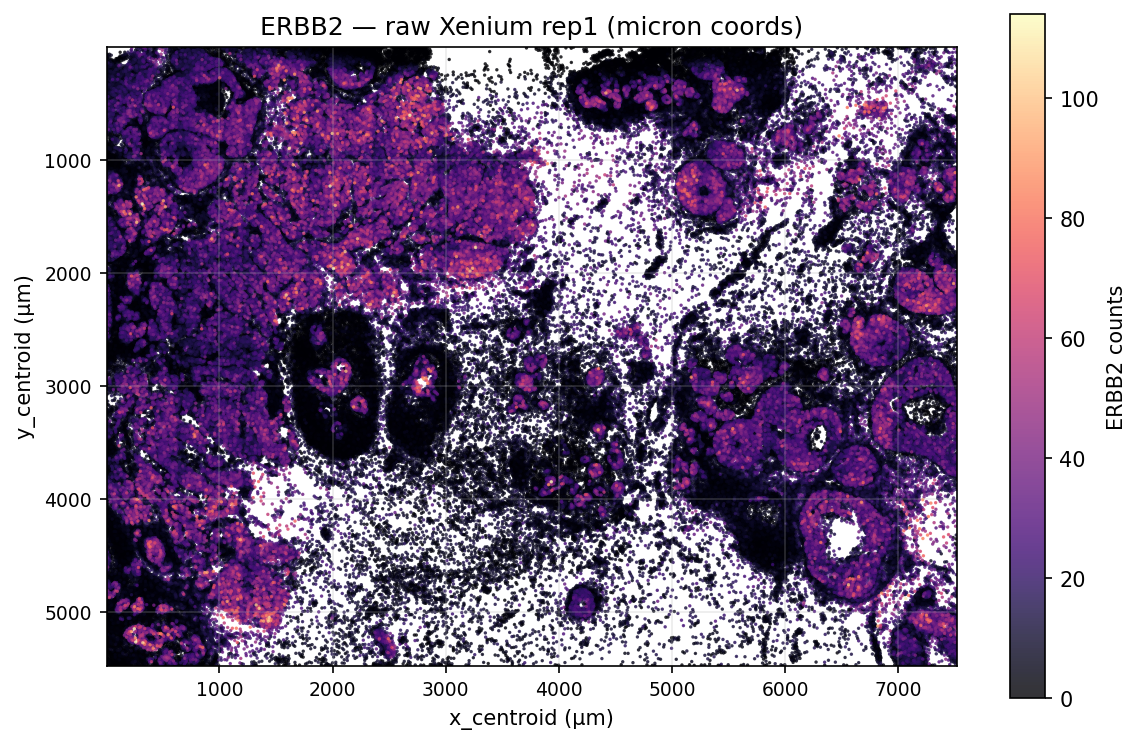

Saved: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/xenium_brca_rep1_ERBB2_raw_microns.png


In [8]:
## ERBB2 expression from raw Xenium outs (rep1), micron coordinates
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

try:
    _brca_root = BRCA_ROOT
    _out_dir = OUTPUT_DIR
except NameError:
    _repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno")
    _brca_root = _repo / "data/Xemium/BRCA"
    _out_dir = _brca_root / "Results"
    _out_dir.mkdir(parents=True, exist_ok=True)

rep1_dir = _brca_root / "human_breast_Xenium_rep1"
prefix = "Xenium_FFPE_Human_Breast_Cancer_Rep1"
matrix_path = rep1_dir / f"{prefix}_cell_feature_matrix.h5"
cells_path = rep1_dir / f"{prefix}_cells.csv.gz"

adata_raw = sc.read_10x_h5(matrix_path)
adata_raw.var_names_make_unique()
cells = pd.read_csv(cells_path)
# Align matrix rows to cells.csv by cell_id / barcode string
cells = cells.copy()
cells["barcode"] = cells["cell_id"].astype(str).str.replace(r"\.0$", "", regex=True)
adata_raw.obs_names = pd.Index(
    pd.Series(adata_raw.obs_names).astype(str).str.replace(r"\.0$", "", regex=True)
)
meta = cells.set_index("barcode")[["x_centroid", "y_centroid"]]
common = adata_raw.obs_names.intersection(meta.index)
adata_raw = adata_raw[common].copy()
adata_raw.obs[["x_centroid", "y_centroid"]] = meta.loc[common, ["x_centroid", "y_centroid"]].to_numpy()
adata_raw.obsm["spatial"] = adata_raw.obs[["x_centroid", "y_centroid"]].to_numpy(float)

if "ERBB2" not in adata_raw.var_names:
    raise KeyError(f"ERBB2 not in raw matrix; genes like {[g for g in adata_raw.var_names if 'ERBB' in g]}")

# Expression vector (dense for one gene)
x = adata_raw[:, "ERBB2"].X
expr = np.asarray(x.toarray() if hasattr(x, "toarray") else x).reshape(-1)
xy = adata_raw.obsm["spatial"]
print(
    f"raw ERBB2: n={len(expr):,}  "
    f"nonzero={(expr>0).mean()*100:.1f}%  "
    f"max={expr.max():.3g}  "
    f"Xµm[{xy[:,0].min():.1f},{xy[:,0].max():.1f}]  "
    f"Yµm[{xy[:,1].min():.1f},{xy[:,1].max():.1f}]"
)

order = np.argsort(expr)
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
sc_plot = ax.scatter(
    xy[order, 0],
    xy[order, 1],
    c=expr[order],
    s=0.4,
    cmap="magma",
    alpha=0.8,
    rasterized=True,
)
cbar = fig.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("ERBB2 counts")
ax.set_xlabel("x_centroid (µm)")
ax.set_ylabel("y_centroid (µm)")
ax.set_title("ERBB2 — raw Xenium rep1 (micron coords)")
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.tick_params(axis="both", which="both", labelsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim(xy[:, 0].min(), xy[:, 0].max())
ax.set_ylim(xy[:, 1].max(), xy[:, 1].min())
fig.tight_layout()
out = _out_dir / "xenium_brca_rep1_ERBB2_raw_microns.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out)


h5ad ERBB2: n=167,780  nonzero=86.6%  max=114
  spatial µm  X[2.1,7523.1] Y[1.4,5476.3]
  spatial_HE  X[5981.9,26705.4] Y[6720.0,21837.9]


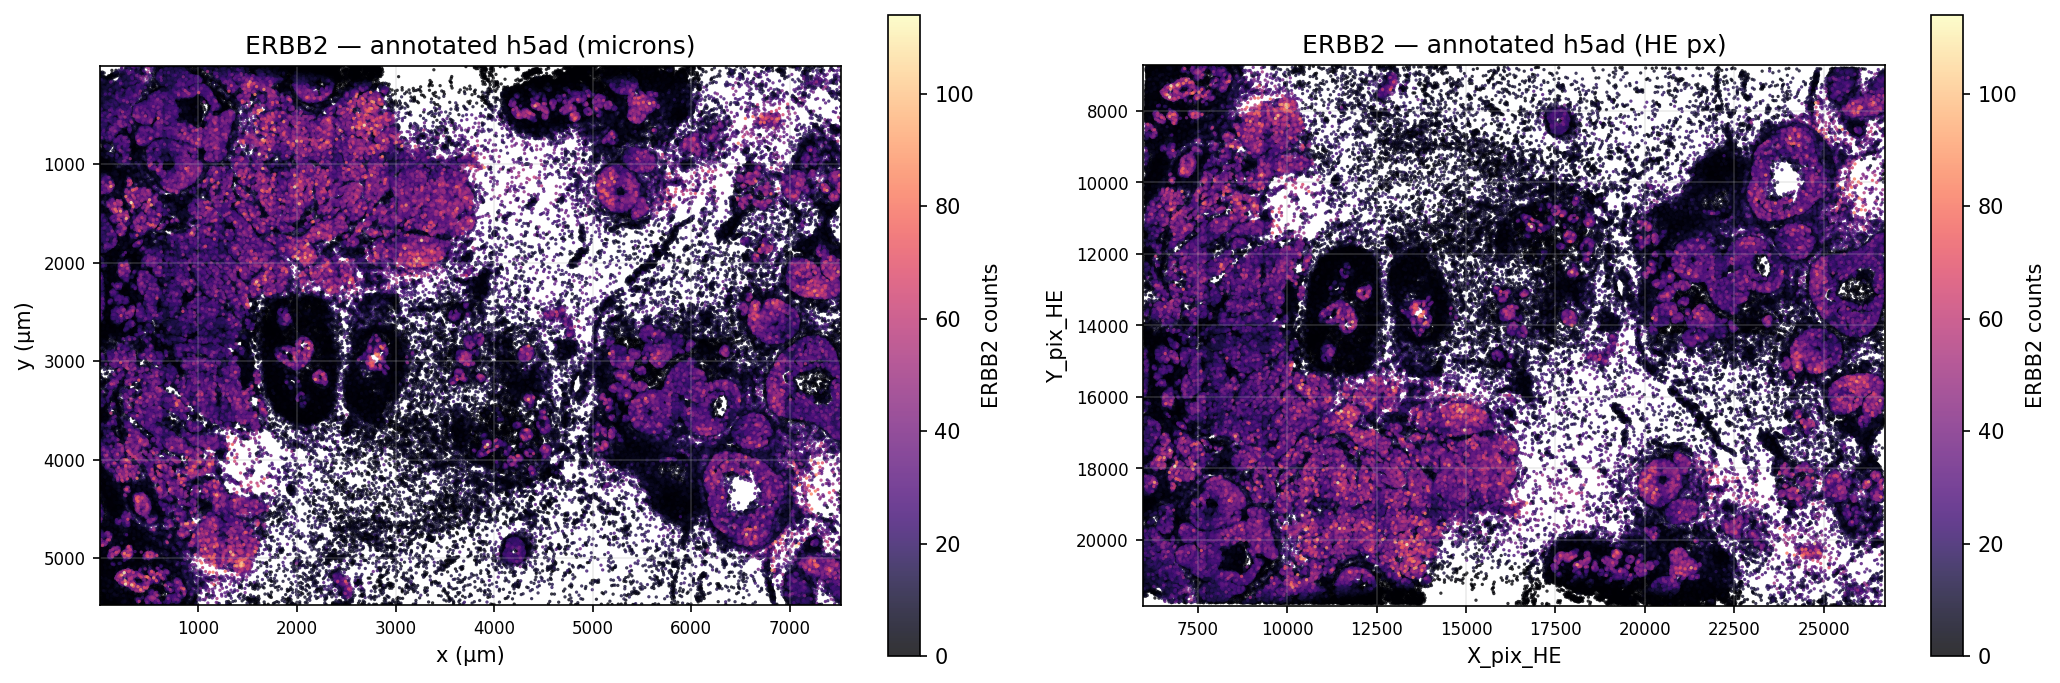

Saved: /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/xenium_brca_rep1_ERBB2_annotated_h5ad.png


In [9]:
## ERBB2 from annotated h5ad (µm + HE TIFF pixels)
from pathlib import Path
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

try:
    _brca_root = BRCA_ROOT
    _out_dir = OUTPUT_DIR
except NameError:
    _repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno")
    _brca_root = _repo / "data/Xemium/BRCA"
    _out_dir = _brca_root / "Results"

h5ad_path = _out_dir / "xenium_brca_rep1_cell_feature_matrix_annotated.h5ad"
adata = ad.read_h5ad(h5ad_path)
if "ERBB2" not in adata.var_names:
    raise KeyError(f"ERBB2 missing in {h5ad_path.name}")

x = adata[:, "ERBB2"].X
expr = np.asarray(x.toarray() if hasattr(x, "toarray") else x).reshape(-1)
xy_um = np.asarray(adata.obsm["spatial"], dtype=float)
xy_he = np.asarray(adata.obsm["spatial_HE"], dtype=float)
print(
    f"h5ad ERBB2: n={len(expr):,}  nonzero={(expr>0).mean()*100:.1f}%  max={expr.max():.3g}"
)
print(
    f"  spatial µm  X[{xy_um[:,0].min():.1f},{xy_um[:,0].max():.1f}] "
    f"Y[{xy_um[:,1].min():.1f},{xy_um[:,1].max():.1f}]"
)
print(
    f"  spatial_HE  X[{xy_he[:,0].min():.1f},{xy_he[:,0].max():.1f}] "
    f"Y[{xy_he[:,1].min():.1f},{xy_he[:,1].max():.1f}]"
)

order = np.argsort(expr)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

for ax, xy, xlab, ylab, title in [
    (axes[0], xy_um, "x (µm)", "y (µm)", "ERBB2 — annotated h5ad (microns)"),
    (axes[1], xy_he, "X_pix_HE", "Y_pix_HE", "ERBB2 — annotated h5ad (HE px)"),
]:
    sc_plot = ax.scatter(
        xy[order, 0],
        xy[order, 1],
        c=expr[order],
        s=0.35,
        cmap="magma",
        alpha=0.8,
        rasterized=True,
    )
    cbar = fig.colorbar(sc_plot, ax=ax, shrink=0.75)
    cbar.set_label("ERBB2 counts")
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.tick_params(axis="both", which="both", labelsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(xy[:, 0].min(), xy[:, 0].max())
    ax.set_ylim(xy[:, 1].max(), xy[:, 1].min())

fig.tight_layout()
out = _out_dir / "xenium_brca_rep1_ERBB2_annotated_h5ad.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out)
